In [ ]:
print("Number of features:", rf.n_features_in_)
print("Features:", X_train.columns.tolist())

Number of features: 16
Features: ['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'soil_ph', 'rainfall', 'soil_fertility_score', 'temp_norm', 'humidity_norm', 'rainfall_norm', 'weather_score', 'nitrogen_norm', 'phosphorus_norm', 'potassium_norm', 'crop_health_index']


In [29]:
import joblib

joblib.dump(rf, "../models/crop_recommendation_model.pkl")

print("Crop Recommendation Model Saved Successfully!")

Crop Recommendation Model Saved Successfully!


In [30]:
import os

print("Model exists:", os.path.exists("../models/crop_recommendation_model.pkl"))
print("Encoder exists:", os.path.exists("../models/crop_label_encoder.pkl"))

Model exists: True
Encoder exists: True


In [4]:
crop = pd.read_csv("../dataset/crop_feature_engineered.csv")

crop.head()

,nitrogen,phosphorus,potassium,temperature,humidity,soil_ph,rainfall,crop,soil_fertility_score,temp_norm,humidity_norm,rainfall_norm,weather_score,nitrogen_norm,phosphorus_norm,potassium_norm,crop_health_index
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,0.365714,0.345886,0.790267,0.656458,0.597537,0.642857,0.264286,0.190,0.481626
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,0.388571,0.371445,0.770633,0.741675,0.627917,0.607143,0.378571,0.180,0.508244
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,0.326905,0.406854,0.793977,0.875710,0.692180,0.428571,0.357143,0.195,0.509543
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,0.305952,0.506901,0.768751,0.799905,0.691853,0.528571,0.214286,0.175,0.498903
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,0.335476,0.324378,0.785626,0.871231,0.660411,0.557143,0.264286,0.185,0.497944


In [5]:
print(crop.shape)

crop.info()

(2200, 17)
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   nitrogen              2200 non-null   int64  
 1   phosphorus            2200 non-null   int64  
 2   potassium             2200 non-null   int64  
 3   temperature           2200 non-null   float64
 4   humidity              2200 non-null   float64
 5   soil_ph               2200 non-null   float64
 6   rainfall              2200 non-null   float64
 7   crop                  2200 non-null   str    
 8   soil_fertility_score  2200 non-null   float64
 9   temp_norm             2200 non-null   float64
 10  humidity_norm         2200 non-null   float64
 11  rainfall_norm         2200 non-null   float64
 12  weather_score         2200 non-null   float64
 13  nitrogen_norm         2200 non-null   float64
 14  phosphorus_norm       2200 non-null   float64
 15  potassium_norm       

In [6]:
X = crop.drop("crop", axis=1)

y = crop["crop"]

print(X.shape)

print(y.shape)

(2200, 16)
(2200,)


In [7]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Label Encoding Completed")

Label Encoding Completed


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1760, 16)
(440, 16)


In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [10]:
y_pred = rf.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9931818181818182


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.95      0.97        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

In [12]:
import joblib

joblib.dump(rf, "../models/crop_recommendation_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [13]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [14]:
crop = pd.read_csv("../dataset/crop_feature_engineered.csv")

print(crop.shape)

crop.head()

(2200, 17)


,nitrogen,phosphorus,potassium,temperature,humidity,soil_ph,rainfall,crop,soil_fertility_score,temp_norm,humidity_norm,rainfall_norm,weather_score,nitrogen_norm,phosphorus_norm,potassium_norm,crop_health_index
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,0.365714,0.345886,0.790267,0.656458,0.597537,0.642857,0.264286,0.190,0.481626
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,0.388571,0.371445,0.770633,0.741675,0.627917,0.607143,0.378571,0.180,0.508244
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,0.326905,0.406854,0.793977,0.875710,0.692180,0.428571,0.357143,0.195,0.509543
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,0.305952,0.506901,0.768751,0.799905,0.691853,0.528571,0.214286,0.175,0.498903
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,0.335476,0.324378,0.785626,0.871231,0.660411,0.557143,0.264286,0.185,0.497944


In [15]:
print(crop.isnull().sum())

nitrogen                0
phosphorus              0
potassium               0
temperature             0
humidity                0
soil_ph                 0
rainfall                0
crop                    0
soil_fertility_score    0
temp_norm               0
humidity_norm           0
rainfall_norm           0
weather_score           0
nitrogen_norm           0
phosphorus_norm         0
potassium_norm          0
crop_health_index       0
dtype: int64


In [16]:
X = crop.drop("crop", axis=1)
y = crop["crop"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (2200, 16)
Target Shape : (2200,)


In [17]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Target Encoded Successfully!")

Target Encoded Successfully!


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (1760, 16)
Testing Data : (440, 16)


In [19]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
    
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [20]:
y_pred = rf.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy : {accuracy:.4f}")

Model Accuracy : 0.9932


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      0.95      0.97        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

<Figure size 1200x1200 with 0 Axes>

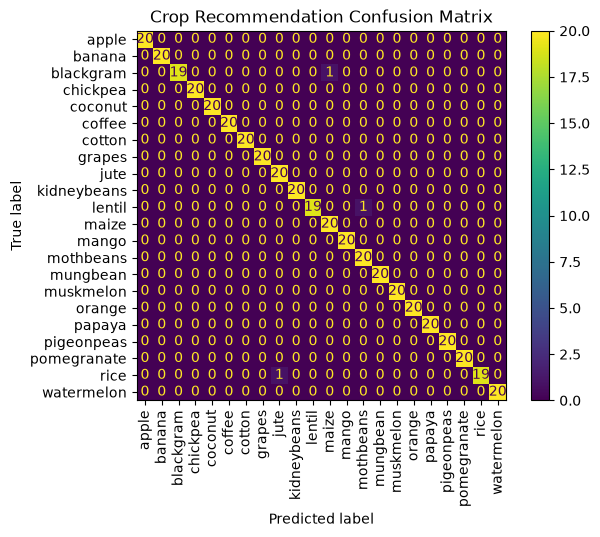

In [23]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

plt.figure(figsize=(12,12))
disp.plot(xticks_rotation=90)
plt.title("Crop Recommendation Confusion Matrix")
plt.show()

In [24]:
joblib.dump(rf, "../models/crop_recommendation_model.pkl")

joblib.dump(encoder, "../models/crop_label_encoder.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [25]:
import joblib

model = joblib.load("../models/crop_recommendation_model.pkl")

print("Model expects:", model.n_features_in_, "features")

Model expects: 16 features


In [26]:
print("Number of features:", rf.n_features_in_)
print("Features:", X_train.columns.tolist())

Number of features: 16
Features: ['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'soil_ph', 'rainfall', 'soil_fertility_score', 'temp_norm', 'humidity_norm', 'rainfall_norm', 'weather_score', 'nitrogen_norm', 'phosphorus_norm', 'potassium_norm', 'crop_health_index']


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Predictions
y_pred = rf.predict(X_test)

# ============================================================
# 1. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Crop Recommendation")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()


# ============================================================
# 2. MULTICLASS ROC CURVE
# ============================================================

y_test_bin = label_binarize(
    y_test,
    classes=rf.classes_
)

y_score = rf.predict_proba(X_test)

plt.figure(figsize=(10, 8))

for i in range(len(rf.classes_)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {rf.classes_[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Crop Recommendation")
plt.legend(
    loc="lower right",
    fontsize=8
)

plt.tight_layout()
plt.show()

NameError: name 'rf' is not defined